<a href="https://colab.research.google.com/github/sharvani1357/AI-Powered-Employee-Attrition-Prediction-System/blob/main/AI_Powered_Employee_Attrition_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


In [2]:
print(df.head())
print(df.shape)
print(df.columns)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [8]:
#Attrition Rate
attrition_rate=(df["Attrition"].value_counts(normalize=True)*100)
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [9]:
#Department wise attrition
pd.crosstab(df["Department"],df["Attrition"])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [10]:
pd.crosstab(df["Gender"],df["Attrition"])

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


In [12]:
df.groupby("Attrition")["MonthlyIncome"].mean()

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


In [13]:
df.groupby("Attrition")["TotalWorkingYears"].mean()

,TotalWorkingYears
Attrition,
No,11.862936
Yes,8.244726


In [14]:
df.select_dtypes(include="object").columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:

    df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   int64
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null 

In [17]:
X = df.drop("Attrition",axis=1)
y = df["Attrition"]

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print(df.info())

print(X_train.shape)

print(X_test.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   int64
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null 

In [20]:
#logistic regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
print("Accuracy")
print(accuracy_score(y_test,y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report")
print(classification_report(y_test,y_pred))

Accuracy
0.891156462585034

Confusion Matrix
[[249   6]
 [ 26  13]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.68      0.33      0.45        39

    accuracy                           0.89       294
   macro avg       0.79      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



In [21]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import export_text
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_pred = dt_model.predict(X_test)
print("Accuracy")
print(accuracy_score(y_test,dt_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,dt_pred))
print("\nClassification Report")
print(classification_report(y_test,dt_pred))
print("\nDecision Tree Rules")
rules = export_text(dt_model,feature_names=list(X.columns))
print(rules[:3000])

Accuracy
0.7653061224489796

Confusion Matrix
[[218  37]
 [ 32   7]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294


Decision Tree Rules
|--- OverTime <= 0.50
|   |--- TotalWorkingYears <= 1.50
|   |   |--- HourlyRate <= 58.50
|   |   |   |--- TrainingTimesLastYear <= 3.50
|   |   |   |   |--- Age <= 33.00
|   |   |   |   |   |--- YearsWithCurrManager <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- YearsWithCurrManager >  0.50
|   |   |   |   |   |   |--- MonthlyRate <= 13729.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- MonthlyRate >  13729.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  33.00
|   |   |   |   |  

In [22]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Accuracy")
print(accuracy_score(y_test,rf_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,rf_pred))
print("\nClassification Report")
print(classification_report(y_test,rf_pred))

Accuracy
0.8673469387755102

Confusion Matrix
[[251   4]
 [ 35   4]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



In [23]:
import pandas as pd
importance = pd.DataFrame({
"Feature": X.columns,"Importance": rf_model.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
print(importance.head(10))

              Feature  Importance
17      MonthlyIncome    0.074968
21           OverTime    0.064823
0                 Age    0.056865
2           DailyRate    0.050505
27  TotalWorkingYears    0.048104
18        MonthlyRate    0.047090
8      EmployeeNumber    0.045296
11         HourlyRate    0.043352
4    DistanceFromHome    0.042012
30     YearsAtCompany    0.041914


In [24]:
#SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
svm_model = SVC(kernel="rbf",random_state=42)
svm_model.fit(X_train_scaled,y_train)
svm_pred = svm_model.predict(X_test_scaled)
print("Accuracy")
print(accuracy_score(y_test,svm_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,svm_pred))
print("\nClassification Report")
print(classification_report(y_test,svm_pred))

Accuracy
0.8843537414965986

Confusion Matrix
[[255   0]
 [ 34   5]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.13      0.23        39

    accuracy                           0.88       294
   macro avg       0.94      0.56      0.58       294
weighted avg       0.90      0.88      0.84       294



In [25]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
knn_pred = knn_model.predict(X_test_scaled)
print("Accuracy")
print(accuracy_score(y_test,knn_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,knn_pred))
print("\nClassification Report")
print(classification_report(y_test,knn_pred))

Accuracy
0.8741496598639455

Confusion Matrix
[[252   3]
 [ 34   5]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.62      0.13      0.21        39

    accuracy                           0.87       294
   macro avg       0.75      0.56      0.57       294
weighted avg       0.85      0.87      0.84       294



In [27]:
#Naive bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
nb_model = GaussianNB()
nb_model.fit(X_train,y_train)
nb_pred = nb_model.predict(X_test)
print("Accuracy")
print(accuracy_score(y_test,nb_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,nb_pred))
print("\nClassification Report")
print(classification_report(y_test,nb_pred))

Accuracy
0.8333333333333334

Confusion Matrix
[[224  31]
 [ 18  21]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       255
           1       0.40      0.54      0.46        39

    accuracy                           0.83       294
   macro avg       0.66      0.71      0.68       294
weighted avg       0.86      0.83      0.84       294



In [28]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Original Shape")
print(X_train_scaled.shape)
print("\nPCA Shape")
print(X_train_pca.shape)
print("\nExplained Variance")
print(pca.explained_variance_ratio_.sum())

Original Shape
(1176, 34)

PCA Shape
(1176, 25)

Explained Variance
0.9609553770679072


In [29]:
#Logistic Regression + PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
lr_pca = LogisticRegression()
lr_pca.fit(X_train_pca,y_train)
lr_pca_pred = lr_pca.predict(X_test_pca)
print("Accuracy")
print(accuracy_score(y_test,lr_pca_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test,lr_pca_pred))
print("\nClassification Report")
print(classification_report(y_test,lr_pca_pred))

Accuracy
0.9013605442176871

Confusion Matrix
[[251   4]
 [ 25  14]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       255
           1       0.78      0.36      0.49        39

    accuracy                           0.90       294
   macro avg       0.84      0.67      0.72       294
weighted avg       0.89      0.90      0.89       294



In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[45569.99999999994, 40990.58631219993, 39317.06271782338, 37686.648335419624, 36596.86212918128, 35572.57319510219, 34850.66632730823, 34378.53256413072, 33992.029368200885, 33587.86180661037]


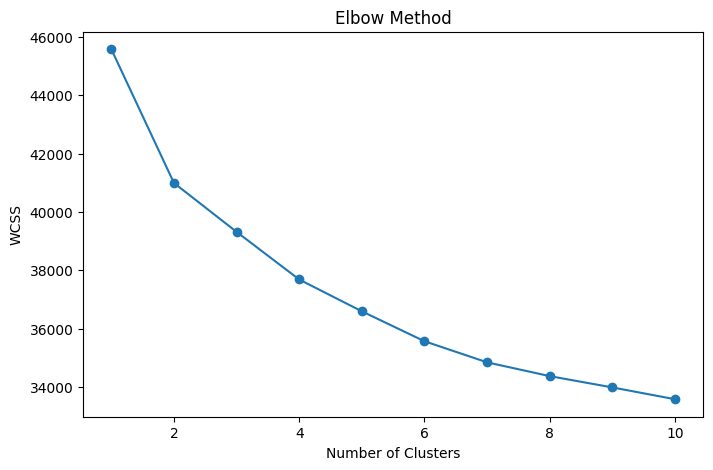

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

print(wcss)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

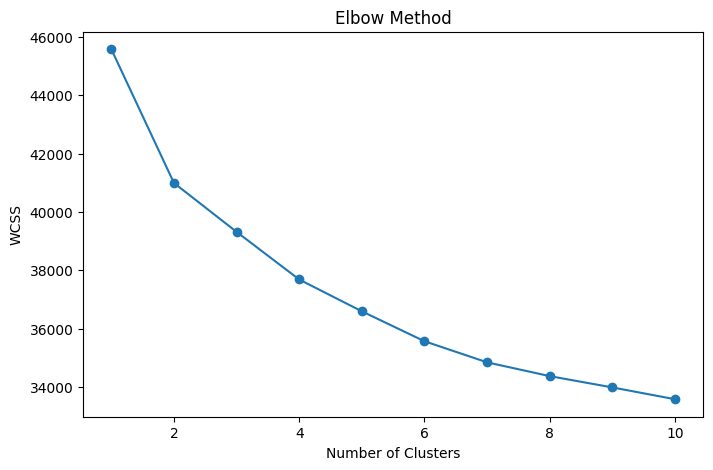

Cluster Counts
Cluster
3    727
1    327
0    221
2    195
Name: count, dtype: int64

Cluster Analysis
               Age  MonthlyIncome  TotalWorkingYears  YearsAtCompany
Cluster                                                             
0        48.009050   15394.221719          25.466063       14.642534
1        36.308869    6227.501529          12.012232       10.449541
2        35.348718    4992.210256           9.123077        5.723077
3        34.253095    4329.177442           7.215956        3.484182

Attrition Distribution by Cluster
Attrition    0    1
Cluster            
0          204   17
1          296   31
2          158   37
3          575  152


In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

df["Cluster"] = clusters

print("Cluster Counts")
print(
    df["Cluster"].value_counts()
)

print("\nCluster Analysis")
print(
    df.groupby("Cluster")[[
        "Age",
        "MonthlyIncome",
        "TotalWorkingYears",
        "YearsAtCompany"
    ]].mean()
)

print("\nAttrition Distribution by Cluster")
print(
    pd.crosstab(
        df["Cluster"],
        df["Attrition"]
    )
)

In [34]:
#decision tree hypertuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_params = {

    "max_depth":[3,5,10,15],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

dt_grid = GridSearchCV(

    DecisionTreeClassifier(
        random_state=42
    ),

    dt_params,

    cv=5,

    scoring="recall"

)

dt_grid.fit(
    X_train,
    y_train
)

print("Best Parameters")
print(
    dt_grid.best_params_
)

print("\nBest Recall Score")
print(
    dt_grid.best_score_
)

Best Parameters
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Recall Score
0.41410256410256413


In [35]:
#randomforest tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,15],

    "min_samples_split":[2,5]

}

rf_grid = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    rf_params,

    cv=5,

    scoring="recall"

)

rf_grid.fit(
    X_train,
    y_train
)

print("Best Parameters")
print(
    rf_grid.best_params_
)

print("\nBest Recall Score")
print(
    rf_grid.best_score_
)

Best Parameters
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}

Best Recall Score
0.20166666666666666


In [36]:
#knn tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_params = {

    "n_neighbors":[3,5,7,9,11,13]

}

knn_grid = GridSearchCV(

    KNeighborsClassifier(),

    knn_params,

    cv=5,

    scoring="recall"

)

knn_grid.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters")
print(
    knn_grid.best_params_
)

print("\nBest Recall Score")
print(
    knn_grid.best_score_
)

Best Parameters
{'n_neighbors': 3}

Best Recall Score
0.1816666666666667


In [37]:
#svm tuning
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_params = {

    "C":[0.1,1,10],

    "kernel":["linear","rbf"]

}

svm_grid = GridSearchCV(

    SVC(),

    svm_params,

    cv=5,

    scoring="recall"

)

svm_grid.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters")
print(
    svm_grid.best_params_
)

print("\nBest Recall Score")
print(
    svm_grid.best_score_
)

Best Parameters
{'C': 10, 'kernel': 'rbf'}

Best Recall Score
0.35397435897435897


In [38]:
import pickle

pickle.dump(
    nb_model,
    open(
        "employee_attrition_model.pkl",
        "wb"
    )
)

print("Model Saved Successfully")

Model Saved Successfully


In [39]:
import pickle

pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

print("Scaler Saved Successfully")

Scaler Saved Successfully
